In [1]:
from typing import Dict, List, TypedDict, Any, Literal, Annotated, Optional, cast
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, END
import operator
import argparse
import sys

from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser, PydanticOutputParser
from langchain_community.embeddings import SentenceTransformerEmbeddings

In [2]:
import dotenv

dotenv.load_dotenv()

True

In [3]:
from langfuse import get_client
 
langfuse = get_client()
 
# Verify connection
if langfuse.auth_check():
    print("Langfuse client is authenticated and ready!")
else:
    print("Authentication failed. Please check your credentials and host.")

Langfuse client is authenticated and ready!


In [4]:
from langfuse.langchain import CallbackHandler


langfuse_handler = CallbackHandler()

In [5]:
# 1. 메모장(State) 확장: 모든 단계의 결과물을 저장할 수 있어야 합니다.
class MyRAGState(TypedDict):
    # 최초 입력
    query: str
    # 제안 요청서 양식에 맞춰 개선한 입력
    dense_query: str
    # dense_query에서 핵심 키워드들만 추출한 입력
    sparse_query: str
    hierarchy_info: List[dict]  # 2-1 결과
    retrieved_docs: Annotated[List[dict], operator.add] # 2-2~2-5 결과 합산
    reranked_context: List[dict] # 2-6 결과
    answer: str

In [6]:
# from hybrid_search_v1.search_graph import graph as step2_graph

In [7]:
import numpy as np
import copy
import json
import sqlite3
import sqlite_vec
from sentence_transformers import SentenceTransformer
from kiwipiepy import Kiwi
from collections import Counter


DB_PATH = "/home/codeitDev/project/AI_7-team/DB/document.db"
MODEL_NAME = "jhgan/ko-sroberta-multitask"

embeddings = SentenceTransformerEmbeddings(model_name=MODEL_NAME)

kiwi = Kiwi()

class SearchState(TypedDict):
    # 검색용 쿼리
    query: str

    # 계층 정보 (필터링 용도)
    scopes: List[Dict]

    # 검색 결과
    scoped_dense_result: List[Dict]
    scoped_sparse_result: List[Dict]
    dense_result: List[Dict]
    sparse_result: List[Dict]

    # 최종 결과
    search_result: List[Dict]


def hierarchy_search(state: SearchState):
    query = state['query']
    query_vec = np.array(embeddings.embed_query(query)).astype('float32')
    with sqlite3.connect(DB_PATH) as conn:
        conn.enable_load_extension(True)
        sqlite_vec.load(conn)
        conn.enable_load_extension(False)
        cursor = conn.cursor()
        cursor.execute("""
            SELECT
                json_extract(h.metadata, '$.doc_id'),
                json_extract(h.metadata, '$.level'),
                json_extract(h.metadata, '$.title'),
                json_extract(p.metadata, '$.level'),
                json_extract(p.metadata, '$.title'),
                v.distance
            FROM hierarchy h
            LEFT JOIN hierarchy p
            ON json_extract(h.metadata, '$.parent_uid')
                = json_extract(p.metadata, '$.uid')
            JOIN hierarchy_vec v ON h.rowid = v.rowid
            WHERE v.text_embedding MATCH ? AND k = 100
        """, (query_vec,))
        results = cursor.fetchall()

        # 성적의 합을 통해, 가장 좋은 문서 50개를 반환한다.
        scores = {}
        counts = {}
        for row in results:
            if counts.get(row[0], 0) == 3:
                continue
            else:
                counts[row[0]] = counts.get(row[0], 0) + 1
                score = 1.0 / (1.0 + row[5])
                scores[row[0]] = scores.get(row[0], 0) + score
        
        sorted_docs = sorted(scores.items(), key=lambda x: -x[1])
        search_results = [doc_id for doc_id, score in sorted_docs[:30]]

    return {'scopes': search_results}


def extract_nouns(query):
    if not query:
        return ""
    tokens: List[Any] = cast(List[Any], kiwi.tokenize(query))
    nouns = [f'"{t.form}"' for t in tokens if t.tag in ('NNG', 'NNP', 'NNB')]
    if len(nouns) == 0:
        return ""
    return " OR ".join(nouns)


def scoped_dense_search(state: SearchState):
    scopes = state['scopes']
    query = state['query']
    query_vec = np.array(embeddings.embed_query(query)).astype('float32')

    results = {}
    with sqlite3.connect(DB_PATH) as conn:
        conn.enable_load_extension(True)
        sqlite_vec.load(conn)
        conn.enable_load_extension(False)
        # 각 scope (계층 정보) 마다
        scope_query = f"""
            WITH scoped_chunks AS (
                SELECT *
                FROM chunks
                WHERE json_extract(metadata, '$.doc_id') IN (SELECT value FROM json_each(?))
            )
            SELECT
                json_extract(c.metadata, '$.uid'),
                c.text,
                c.metadata,
                v.distance
            FROM scoped_chunks c
            JOIN chunks_vec v ON c.rowid = v.rowid
            WHERE v.text_embedding MATCH ? AND k = 30
        """
        cursor = conn.cursor()
        cursor.execute(scope_query, (json.dumps(list(scopes)), query_vec,))
        results = cursor.fetchall()
        results = [row for row in results]
        results = sorted(results, key=lambda x: x[3])
        
        # 'uid': ('text', 'metadata') 형식이다.
        results = [{result[0]:(result[1], json.loads(result[2]))} for result in results]

    return {'scoped_dense_result': results}


def scoped_sparse_search(state: SearchState):
    scopes = state['scopes']
    query = extract_nouns(state['query'].strip())
    # 단어 단위의 OR를 사용한다.
    # 추후 bigram 변경 계획이 있다.
    if len(query) == 0:
        return {'scoped_sparse_result': []}

    with sqlite3.connect(DB_PATH) as conn:
        conn.enable_load_extension(True)
        sqlite_vec.load(conn)
        conn.enable_load_extension(False)
        cursor = conn.cursor()
        cursor.execute("""
            SELECT 
                doc_id,
                uid,
                snippet(sparse, 1, '[', ']', '...', 20),
                bm25(sparse) as score
                FROM sparse
                WHERE nouns MATCH ? AND doc_id IN (SELECT value FROM json_each(?))
                ORDER BY score
                LIMIT 30
        """, (query, json.dumps(list(scopes)),))

        sparse_result = cursor.fetchall()
        uids = [r[1] for r in sparse_result]
        
        if len(uids) > 0:
            cursor.execute(f"""
                SELECT 
                    json_extract(metadata, '$.uid'), 
                    text,
                    metadata
                FROM chunks
                WHERE json_extract(metadata, '$.uid') IN (SELECT value FROM json_each(?))
            """, (json.dumps(list(uids)),))

            final_results = cursor.fetchall()

            final_results = {a: (b, json.loads(c)) for a, b, c in final_results}

            final_results = [{uid: final_results[uid]} for uid in uids]
        else:
            final_results = []
    if len(final_results) >= 30:
        final_results = final_results[:30]
    return {'scoped_sparse_result': final_results}


def dense_search(state: SearchState):
    query = state['query']
    query_vec = np.array(embeddings.embed_query(query)).astype('float32')

    with sqlite3.connect(DB_PATH) as conn:
        conn.enable_load_extension(True)
        sqlite_vec.load(conn)
        conn.enable_load_extension(False)
        cursor = conn.cursor()
        cursor.execute("""
            SELECT
                json_extract(c.metadata, '$.uid'),
                c.text,
                c.metadata
            FROM chunks c
            JOIN chunks_vec v ON c.rowid = v.rowid
            WHERE v.text_embedding MATCH ? AND k = 30
        """, (query_vec,))
        results = cursor.fetchall()

        # 'uid': ('text', 'metadata') 형식이다.
        search_results = []
        for result in results:
            search_results.append({result[0]: (result[1], json.loads(result[2]))})

    return {'dense_result': search_results}


def sparse_search(state: SearchState):
    query = extract_nouns(state['query'].strip())
    # 단어 단위의 OR를 사용한다.
    # 추후 bigram 변경 계획이 있다.
    if len(query) == 0:
        return {'sparse_result': []}

    with sqlite3.connect(DB_PATH) as conn:
        conn.enable_load_extension(True)
        sqlite_vec.load(conn)
        conn.enable_load_extension(False)
        cursor = conn.cursor()
        cursor.execute("""
            SELECT 
                uid,
                snippet(sparse, 1, '[', ']', '...', 20),
                bm25(sparse) as score
                FROM sparse
                WHERE nouns MATCH ?
                ORDER BY score
                LIMIT 30
        """, (query,))

        sparse_result = cursor.fetchall()
        uids = [r[0] for r in sparse_result]
        
        if len(uids) > 0:
            cursor.execute(f"""
                SELECT 
                    json_extract(metadata, '$.uid'), 
                    text,
                    metadata
                FROM chunks
                WHERE json_extract(metadata, '$.uid') IN (SELECT value FROM json_each(?))
            """, (json.dumps(list(uids)),))

            final_results = cursor.fetchall()

            final_results = {a: (b, json.loads(c)) for a, b, c in final_results}

            final_results = [{uid: final_results[uid]} for uid in uids]
        else:
            final_results = []
    return {'sparse_result': final_results}


def rrf(state: SearchState):
    RRF_K = 60
    
    def compute_scores(result_list):
        scores = {}
        for i, d in enumerate(result_list):
            doc_id = next(iter(d.keys()))
            scores[doc_id] = 1 / (i + RRF_K + 1)
        return scores

    # RRF 계산
    scoped_dense_scores = compute_scores(state['scoped_dense_result'])
    scoped_sparse_scores = compute_scores(state['scoped_sparse_result'])
    dense_scores = compute_scores(state['dense_result'])
    sparse_scores = compute_scores(state['sparse_result'],)

    # 검색된 전체 데이터에 대해, doc_id: title 매핑을 수행
    total_docs = {}
    for result_list in [
        state['scoped_dense_result'],
        state['scoped_sparse_result'],
        state['dense_result'],
        state['sparse_result']
    ]:
        for d in result_list:
            total_docs.update(d)

    # doc_id: score 매핑을 수행 - 동일 문서가 여러 번 나오면 합을 계산
    total_scores = {}

    for score_dict in [
        dense_scores,
        sparse_scores,
        scoped_dense_scores,
        scoped_sparse_scores
    ]:
        for doc_id, score in score_dict.items():
            total_scores[doc_id] = total_scores.get(doc_id, 0) + score

    score_list = sorted(total_scores.items(), key=lambda x: -x[1])

    result = [total_docs[k] for k, v in score_list[:30]]
    return {'search_result': result}

/tmp/ipykernel_16968/1046056631.py:14: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name=MODEL_NAME)


In [8]:
search_workflow = StateGraph(SearchState)

search_workflow.add_node("hierarchy", hierarchy_search)

search_workflow.add_node("scoped_dense", scoped_dense_search)
search_workflow.add_node("scoped_sparse", scoped_sparse_search)
search_workflow.add_node("dense", dense_search)
search_workflow.add_node("sparse", sparse_search)

search_workflow.add_node("rrf", rrf)

search_workflow.set_entry_point("hierarchy")

search_workflow.add_edge("hierarchy", "scoped_dense")
search_workflow.add_edge("hierarchy", "scoped_sparse")
search_workflow.add_edge("hierarchy", "dense")
search_workflow.add_edge("hierarchy", "sparse")

search_workflow.add_edge("scoped_dense", "rrf")
search_workflow.add_edge("scoped_sparse", "rrf")
search_workflow.add_edge("dense", "rrf")
search_workflow.add_edge("sparse", "rrf")
search_workflow.add_edge("rrf", END)

In [9]:
app = search_workflow.compile()

In [10]:
import os
import re
import random
from kiwipiepy import Kiwi

kiwi = Kiwi()


def split_paragraphs(md_text):
    # 빈 줄 기준 분리
    paragraphs = re.split(r"\n\s*\n", md_text)
    # 너무 짧은 문단 제거
    paragraphs = [p.strip() for p in paragraphs if len(p.strip()) > 200]
    return paragraphs


def split_sentences(paragraph):
    # 간단한 문장 분리 (과도한 regex 지양)
    sentences = re.split(r"(?<=[.!?다요])\s+", paragraph)
    return [s.strip() for s in sentences if len(s.strip()) > 30]


def sanitize_for_fts5(query: str) -> str:
    # 허용되는 문자만 남기고 제거
    return re.sub(r"[^가-힣a-zA-Z0-9\s]", "", query).strip()


def generate_queries_from_markdown(md_path):
    with open(md_path, "r", encoding="utf-8") as f:
        text = f.read()

    paragraphs = split_paragraphs(text)

    dense_queries = []
    sparse_queries = []
    hybrid_queries = []

    while len(dense_queries) < 2 or \
          len(sparse_queries) < 2 or \
          len(hybrid_queries) < 2:

        p = random.choice(paragraphs)
        sentences = split_sentences(p)

        if not sentences:
            continue

        s = random.choice(sentences)

        # ---- Dense ----
        if len(dense_queries) < 2:
            start = random.randint(0, max(1, len(s)//4))
            end = random.randint(len(s)//2, len(s))
            # q = s[start:end]
            q = s
            # if 60 <= len(q) <= 120:
            dense_queries.append({
                "query": q,
                "original": s
            })

        # ---- Sparse ----
        if len(sparse_queries) < 2:
            nouns = extract_nouns(s)
            if not nouns:
                continue
            nouns = nouns.strip().split()
            # if len(nouns) >= 5:
            # selected = nouns[:7]
            q = " ".join(nouns)
            q = sanitize_for_fts5(q)
            if len(q) >= 3:
                sparse_queries.append({
                    "query": q,
                    "original": s
                })

        # ---- Hybrid ----
        if len(hybrid_queries) < 2:
            nouns = extract_nouns(s)
            if not nouns:
                continue
            nouns = nouns.strip().split()
            # if len(nouns) >= 3:
            # selected = nouns[:3]
            
            '''start = random.randint(0, max(1, len(s)//3))
            end = min(len(s), start + 60)
            base = s[start:end]'''
            q = s + " " + " ".join(nouns)
            q = sanitize_for_fts5(q)
            if len(q) >= 3:
                hybrid_queries.append({
                    "query": q,
                    "original": s
                })

    return {
        "dense": dense_queries[:2],
        "sparse": sparse_queries[:2],
        "hybrid": hybrid_queries[:2],
    }

In [11]:
def generate_all_queries(folder_path):
    results = {}

    for file in os.listdir(folder_path):
        if file.endswith(".md") and file.startswith("step2"):
            path = os.path.join(folder_path, file)
            results[file] = generate_queries_from_markdown(path)

    return results

In [12]:
def run_self_retrieval_test(md_path, retriever):
    queries = generate_queries_from_markdown(md_path)

    stats = {
        "dense": {"hit": 0, "total": 0, "ranks": []},
        "sparse": {"hit": 0, "total": 0, "ranks": []},
        "hybrid": {"hit": 0, "total": 0, "ranks": []},
    }

    for q_type in ["dense", "sparse", "hybrid"]:

        for item in queries[q_type]:
            query_text = item["query"]
            original_sentence = item["original"]

            # ✅ retriever 실행
            result = retriever.invoke({"query": query_text})
            retrieved_chunks = result['search_result']  # 네 구조에 맞게 수정

            hit = False

            for rank, doc in enumerate(retrieved_chunks):
                if original_sentence.replace(" ", "").replace("\n", "") in doc[0].replace(" ", "").replace("\n", ""):
                    stats[q_type]["hit"] += 1
                    stats[q_type]["ranks"].append(rank + 1)
                    hit = True
                    break

            stats[q_type]["total"] += 1

    return stats

In [13]:
def run_full_evaluation(folder_path, retriever):
    files = [f for f in os.listdir(folder_path)
             if f.startswith("step2") and f.endswith(".md")]

    aggregate = {
        "dense": {"hit": 0, "total": 0, "ranks": []},
        "sparse": {"hit": 0, "total": 0, "ranks": []},
        "hybrid": {"hit": 0, "total": 0, "ranks": []},
    }

    for file in files:
        path = os.path.join(folder_path, file)
        stats = run_self_retrieval_test(path, retriever)

        for k in aggregate:
            aggregate[k]["hit"] += stats[k]["hit"]
            aggregate[k]["total"] += stats[k]["total"]
            aggregate[k]["ranks"].extend(stats[k]["ranks"])
        print(aggregate)

    return aggregate

In [14]:
def print_results(aggregate):

    total_hit = 0
    total_total = 0

    for k in ["dense", "sparse", "hybrid"]:
        hit = aggregate[k]["hit"]
        total = aggregate[k]["total"]
        ranks = aggregate[k]["ranks"]

        recall = hit / total if total else 0
        avg_rank = sum(ranks)/len(ranks) if ranks else None
        mrr = sum(1/r for r in ranks)/total if total else 0

        print(f"\n[{k.upper()}]")
        print(f"Recall: {recall:.3f}")
        print(f"Avg Rank: {avg_rank}")
        print(f"MRR: {mrr:.3f}")

        total_hit += hit
        total_total += total

    if total_total:
        print("\n[OVERALL]")
        print(f"Recall: {total_hit/total_total:.3f}")

In [15]:
aggregate = run_full_evaluation('/home/codeitDev/project/AI_7-team/output', app)
print_results(aggregate)

{'dense': {'hit': 1, 'total': 2, 'ranks': [1]}, 'sparse': {'hit': 1, 'total': 2, 'ranks': [24]}, 'hybrid': {'hit': 0, 'total': 2, 'ranks': []}}
{'dense': {'hit': 3, 'total': 4, 'ranks': [1, 12, 5]}, 'sparse': {'hit': 3, 'total': 4, 'ranks': [24, 13, 24]}, 'hybrid': {'hit': 2, 'total': 4, 'ranks': [8, 27]}}
{'dense': {'hit': 4, 'total': 6, 'ranks': [1, 12, 5, 1]}, 'sparse': {'hit': 4, 'total': 6, 'ranks': [24, 13, 24, 1]}, 'hybrid': {'hit': 3, 'total': 6, 'ranks': [8, 27, 2]}}
{'dense': {'hit': 6, 'total': 8, 'ranks': [1, 12, 5, 1, 1, 2]}, 'sparse': {'hit': 6, 'total': 8, 'ranks': [24, 13, 24, 1, 5, 18]}, 'hybrid': {'hit': 5, 'total': 8, 'ranks': [8, 27, 2, 1, 4]}}
{'dense': {'hit': 7, 'total': 10, 'ranks': [1, 12, 5, 1, 1, 2, 1]}, 'sparse': {'hit': 7, 'total': 10, 'ranks': [24, 13, 24, 1, 5, 18, 5]}, 'hybrid': {'hit': 6, 'total': 10, 'ranks': [8, 27, 2, 1, 4, 21]}}
{'dense': {'hit': 9, 'total': 12, 'ranks': [1, 12, 5, 1, 1, 2, 1, 9, 23]}, 'sparse': {'hit': 9, 'total': 12, 'ranks': [24,

In [337]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

class OverallState(SearchState):
    # 사용자 질의
    query: str

    # 최종 검색 결과
    search_result: List[Dict]

    # LLM이 생성한 최종 답변
    answer: str

In [352]:
def generate_answer(state: OverallState):
    # 검색 결과 가공 (uid: (text, metadata))
    context_list = []
    for doc in state['search_result']:
        text, meta = doc
        # RFP 답변의 신뢰도를 위해 출처 정보를 포함하여 컨텍스트 구성
        context_list.append(f"[{meta.get('document_title', '알 수 없는 섹션')}]\n{text}")
    
    context_text = "\n\n---\n\n".join(context_list)
    
    prompt = ChatPromptTemplate.from_template("""
        당신은 제안 요청서(RFP) 분석 전문가입니다. 
        아래 제공된 [컨텍스트]만을 바탕으로 사용자의 [질문]에 대해 정확하고 전문적인 답변을 작성하세요.

        [주의 사항]
        1. 반드시 제공된 컨텍스트에 근거하여 답변하세요. 
        2. 만약 컨텍스트에서 답을 찾을 수 없다면 "제공된 문서 내에서 관련 내용을 찾을 수 없습니다"라고 답하세요.
        3. 답변 시 해당 내용이 포함된 섹션 제목([제목])을 언급하여 출처를 밝히세요.
        4. RFP의 공식적인 톤앤매너를 유지하세요.

        [컨텍스트]
        {context}

        [질문]
        {query}
    """)
    
    llm = ChatOpenAI(model="gpt-5-mini", temperature=0) # RFP는 정확도가 중요하므로 temp=0 권장
    chain = prompt | llm | StrOutputParser()
    
    response = chain.invoke({
        "context": context_text,
        "query": state['query']
    })
    
    return {"answer": response}

In [353]:
# 메인 워크플로우 선언
main_workflow = StateGraph(OverallState)

# 1. 검색 그래프 호출 노드 (이미 컴파일된 app 사용)
def call_search_graph(state: OverallState):
    # 기존 검색 그래프 실행
    search_output = app.invoke({"query": state['query']})
    return search_output

# 노드 추가
main_workflow.add_node("search_step", app)
main_workflow.add_node("answer_step", generate_answer)

# 엣지 연결
main_workflow.set_entry_point("search_step")
main_workflow.add_edge("search_step", "answer_step")
main_workflow.add_edge("answer_step", END)

# 최종 컴파일
final_app = main_workflow.compile()

In [ ]:
def recall_at_k(gold_uid, predicted_uids, k):
    return int(gold_uid in predicted_uids[:k])

In [ ]:
def reciprocal_rank(gold_uid, predicted_uids):
    for i, uid in enumerate(predicted_uids):
        if uid == gold_uid:
            return 1 / (i + 1)
    return 0

In [ ]:
def evaluate(dataset, retriever, k=10):
    recalls = []
    rr_scores = []

    for sample in dataset:
        results = retriever(sample["query"])
        predicted = [r["uid"] for r in results]

        recalls.append(recall_at_k(sample["gold_uid"], predicted, k))
        rr_scores.append(reciprocal_rank(sample["gold_uid"], predicted))

    print("Recall@{}: {:.4f}".format(k, sum(recalls)/len(recalls)))
    print("MRR: {:.4f}".format(sum(rr_scores)/len(rr_scores)))

In [9]:
import sqlite3
import json
from typing import List, Dict, Any
from collections import defaultdict
from kiwipiepy import Kiwi


kiwi = Kiwi()

DB_PATH = "DB/document.db"

def fetch_doc_representatives(limit=None):
    """
    문서별:
        - doc_id
        - 대표 title (hierarchy)
        - 대표 chunk 1개
    """
    docs = []

    with sqlite3.connect(DB_PATH) as conn:
        cursor = conn.cursor()

        # 1. 문서별 대표 title (가장 상위 level 기준 가정)
        cursor.execute("""
            SELECT 
                json_extract(metadata, '$.doc_id') as doc_id,
                json_extract(metadata, '$.title') as title
            FROM hierarchy
            WHERE json_extract(metadata, '$.level') = 0
        """)

        doc_titles = cursor.fetchall()

        for doc_id, title in doc_titles:
            # 2. 각 문서의 첫 번째 chunk 하나
            cursor.execute("""
                SELECT text
                FROM chunks
                WHERE json_extract(metadata, '$.doc_id') = ?
                LIMIT 1
            """, (doc_id,))
            
            row = cursor.fetchone()
            representative_chunk = row[0] if row else ""

            docs.append({
                "doc_id": doc_id,
                "title": title or "",
                "chunk": representative_chunk or ""
            })

            if limit and len(docs) >= limit:
                break

    return docs

In [10]:
def extract_nouns_simple(text: str, max_n=4):
    tokens = kiwi.tokenize(text)
    nouns = [t.form for t in tokens if t.tag in ('NNG', 'NNP', 'NNB')]
    return nouns[:max_n]

In [11]:
def generate_queries_per_doc(doc: Dict[str, Any]) -> List[Dict[str, Any]]:
    queries = []
    doc_id = doc["doc_id"]
    title = doc["title"]
    chunk = doc["chunk"]

    # 1️⃣ 제목 그대로
    if title.strip():
        queries.append({
            "query": title.strip(),
            "gold_doc_id": doc_id
        })

    # 2️⃣ title 기반 명사 조합
    title_nouns = extract_nouns_simple(title)
    if len(title_nouns) >= 2:
        q = " ".join(title_nouns[:2])
        queries.append({
            "query": q,
            "gold_doc_id": doc_id
        })

    # 3️⃣ chunk 기반 명사 조합
    chunk_nouns = extract_nouns_simple(chunk)
    if len(chunk_nouns) >= 3:
        q = " ".join(chunk_nouns[:3])
        queries.append({
            "query": q,
            "gold_doc_id": doc_id
        })

    return queries

In [12]:
def build_test_set(limit_docs=None):
    docs = fetch_doc_representatives(limit_docs)
    test_cases = []

    for doc in docs:
        qs = generate_queries_per_doc(doc)
        test_cases.extend(qs)

    return test_cases

In [13]:
def evaluate(app, test_cases, top_k=10):
    hits = 0
    reciprocal_ranks = []

    for case in test_cases:
        query = case["query"]
        gold = case["gold_doc_id"]

        result = app.invoke({"query": query})
        retrieved = result["search_result"]

        found = False
        for rank, item in enumerate(retrieved[:top_k]):
            uid = next(iter(item.keys()))
            metadata = item[uid][1]
            if metadata.get("doc_id") == gold:
                hits += 1
                reciprocal_ranks.append(1 / (rank + 1))
                found = True
                break
        
        if not found:
            reciprocal_ranks.append(0)

    accuracy = hits / len(test_cases)
    mrr = sum(reciprocal_ranks) / len(test_cases)

    return {
        "total_cases": len(test_cases),
        "top_k_accuracy": accuracy,
        "mrr": mrr
    }

In [ ]:
# 2. 순서도(Graph) 준비하기
main_workflow = StateGraph(MyRAGState)

# 3. 일꾼(Nodes) 정의

# --- 1단계: 계층형 검색 (2-1 ~ 2-6) ---
main_workflow.add_node("search_step", step2_graph)




# --- 2단계: 최종 합성 ---
def final_synthesis(state: MyRAGState):
    print("--- 4단계: 검색된 정보를 종합하여 최종 답변 작성 ---")
    return {"answer": "최종 완성된 답변"}

# 4. 순서도(Graph) 그리기

main_workflow.add_node("hierarchy", hierarchy_search)
main_workflow.add_node("search_h", hybrid_search_with_h)
main_workflow.add_node("search_global", hybrid_search_global)
main_workflow.add_node("rerank", rerank_results)
main_workflow.add_node("final_step", final_synthesis)

# 연결 (Edges)
main_workflow.set_entry_point("hierarchy")

main_workflow.add_edge("hierarchy", "search_h")
main_workflow.add_edge("hierarchy", "search_global") # 병렬 실행 가능
main_workflow.add_edge("search_h", "rerank")
main_workflow.add_edge("search_global", "rerank")
main_workflow.add_edge("rerank", "final_step")
main_workflow.add_edge("final_step", END)

app = main_workflow.compile()

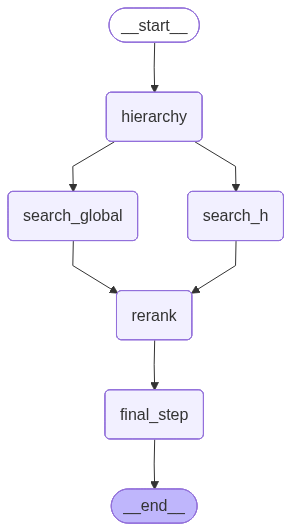

In [54]:
app

In [55]:
def main(args):
    print(args)
    app.invoke(input = {'query': args.query}, config={"callbacks": [langfuse_handler]})

In [59]:
if __name__ == '__main__':
    parser = argparse.ArgumentParser(description="Example script")

    parser.add_argument("-q", "--query", type=str, required=True, help="Query")
    args = parser.parse_args(args=["-q", "고려대학교 학사"])
    main(args)

Namespace(query='고려대학교 학사')
--- 2-1단계: Hierarchy 테이블 검색 ---
{'document_name': '비교과시스템개발사업제안요청서'} 을지대학교
{'document_name': '학업성취도 다차원 종단분석 통합시스템 1차 고도화'} [사전공개용]
{'document_name': '서영대학교차세대교육혁신지원시스템'} 사업개요
{'document_name': '실손보험청구전산화시스템구축'} 사업개요
{'document_name': '년도차세대응급의료상황관리시스템구축'} 사업개요
{'document_name': '년도차세대응급의료상황관리시스템구축'} 사업개요 > 이현응급의료에서가장취약한영역
{'document_name': '년도차세대응급의료상황관리시스템구축'} 사업개요 > 응급의료정보충실도향상
{'document_name': '년도차세대응급의료상황관리시스템구축'} 사업개요 > 녹취및관련솔루션
{'document_name': '서울디지털성범죄안심지원센터업무시스템및'} 사업추진방안
{'document_name': '대용량자료전송시스템고도화'} 주요사업내용
--- 2-4~2-5단계: 전역 검색 (Dense/Sparse) ---
--- 2-2~2-3단계: 계층 필터 적용 검색 (Dense/Sparse) ---
--- 2-6단계: Dedup 및 Rerank 수행 ---
--- 4단계: 검색된 정보를 종합하여 최종 답변 작성 ---


In [2]:
import os


os.getcwd()

'/home/codeitDev/project/AI_7-team'

In [20]:
import sqlite3
import json
import numpy as np
import sqlite_vec
from typing import List, Dict, Tuple, Optional
from dataclasses import dataclass
from kiwipiepy import Kiwi
from sentence_transformers import SentenceTransformer

# DB 경로 및 모델 설정
DB_PATH = "DB/document.db"
MODEL_NAME = "jhgan/ko-sroberta-multitask"

@dataclass
class SearchResult:
    rowid: int
    text: str
    metadata: Dict
    score: float
    source: str  # 'dense_scope', 'dense_global', 'sparse_scope', 'sparse_global'

class HybridRetriever:
    def __init__(self, db_path: str, model_name: str):
        self.db_path = db_path
        self.model = SentenceTransformer(model_name)
        self.kiwi = Kiwi()
        
        # DB 연결 및 확장 로드
        self.conn = sqlite3.connect(self.db_path)
        self.conn.enable_load_extension(True)
        sqlite_vec.load(self.conn)
        self.conn.row_factory = sqlite3.Row

    def close(self):
        self.conn.close()

    def _embed_query(self, query: str) -> bytes:
        vec = self.model.encode(query)
        return np.array(vec, dtype=np.float32).tobytes()

    def _extract_nouns(self, text: str) -> str:
        tokens = self.kiwi.tokenize(text)
        nouns = [t.form for t in tokens if t.tag in ('NNG', 'NNP', 'NNB')]
        return " ".join(nouns)

    def search_hierarchy_anchor(self, query_vec: bytes, top_k: int = 1) -> List[Dict]:
        """[Step 1] Hierarchy 테이블에서 Anchor 섹션을 찾습니다."""
        sql = f"""
            SELECT h.text, h.metadata, v.distance
            FROM hierarchy h
            JOIN hierarchy_vec v ON h.rowid = v.rowid
            WHERE v.text_embedding MATCH ? AND k = {top_k}
            ORDER BY v.distance
        """
        cursor = self.conn.cursor()
        cursor.execute(sql, (query_vec,))
        
        results = []
        for row in cursor.fetchall():
            meta = json.loads(row['metadata'])
            results.append({
                'text': row['text'],
                'metadata': meta,
                'distance': row['distance']
            })
        return results

    def search_dense(self, query_vec: bytes, scope: Optional[Dict], top_k: int = 10) -> List[SearchResult]:
        """Dense Vector Search 수행 (Scope 적용/미적용)"""
        sql = f"""
            SELECT c.rowid, c.text, c.metadata, v.distance
            FROM chunks c
            JOIN chunks_vec v ON c.rowid = v.rowid
            WHERE v.text_embedding MATCH ? AND k = {top_k}
        """
        params = [query_vec]

        # Scope 필터링
        if scope:
            sql += " AND json_extract(c.metadata, '$.doc_id') = ?"
            params.extend([scope['doc_id']])
            source_tag = "dense_scope"
        else:
            source_tag = "dense_global"

        sql += " ORDER BY v.distance"

        cursor = self.conn.cursor()
        cursor.execute(sql, params)
        
        results = []
        for row in cursor.fetchall():
            results.append(SearchResult(
                rowid=row['rowid'],
                text=row['text'],
                metadata=json.loads(row['metadata']),
                score=row['distance'], 
                source=source_tag
            ))
        return results

    def search_sparse(self, query_nouns: str, scope: Optional[Dict], top_k: int = 10) -> List[SearchResult]:
        """
        [수정됨] Sparse Search 수행 (2단계 쿼리 패턴 적용)
        가이드 6.1항 및 10.6항 준수: FTS5 단독 검색 후 Chunks 조회
        """
        if not query_nouns.strip():
            return []

        fts_query = " AND ".join([f'"{n}"' for n in query_nouns.split()])
        cursor = self.conn.cursor()
        
        # [Step 1] FTS5 단독 검색 (빠름)
        # Scope가 있다면 doc_id로 1차 필터링 (FTS5 테이블의 doc_id 컬럼 활용)
        if scope:
            fts_sql = "SELECT uid, bm25(sparse) as score FROM sparse WHERE doc_id = ? AND nouns MATCH ? ORDER BY bm25(sparse) LIMIT ?"
            # 필터링 후 chunk_order 검증을 위해 넉넉하게 가져옴 (3배수)
            fetch_limit = top_k * 3
            cursor.execute(fts_sql, (scope['doc_id'], fts_query, fetch_limit))
        else:
            fts_sql = "SELECT uid, bm25(sparse) as score FROM sparse WHERE nouns MATCH ? ORDER BY bm25(sparse) LIMIT ?"
            fetch_limit = top_k
            cursor.execute(fts_sql, (fts_query, fetch_limit))
            
        sparse_hits = cursor.fetchall() # [(uid, score), ...]

        results = []
        source_tag = "sparse_scope" if scope else "sparse_global"

        # [Step 2] uid별 chunks 조회 및 2차 필터링
        # idx_chunks_uid 인덱스를 활용하여 매우 빠름 (~0.06s)
        for uid, bm25_score in sparse_hits:
            chunk_sql = "SELECT rowid, text, metadata FROM chunks WHERE json_extract(metadata, '$.uid') = ?"
            cursor.execute(chunk_sql, (uid,))
            row = cursor.fetchone()
            
            if not row: continue

            meta = json.loads(row['metadata'])
            
            # Scope의 chunk_order 범위 정밀 검증
            if scope:
                # doc_id는 Step 1에서 걸렀지만 안전을 위해 이중 확인
                if meta['doc_id'] != scope['doc_id']: continue
            
            results.append(SearchResult(
                rowid=row['rowid'],
                text=row['text'],
                metadata=meta,
                score=bm25_score,
                source=source_tag
            ))
            
            if len(results) >= top_k:
                break
                
        return results

    def _rrf_fusion(self, search_results_list: List[List[SearchResult]], k: int = 60) -> List[SearchResult]:
        """RRF Fusion"""
        scores: Dict[int, float] = {}
        rowid_map: Dict[int, SearchResult] = {}
        
        for result_list in search_results_list:
            for rank, item in enumerate(result_list):
                if item.rowid not in rowid_map:
                    rowid_map[item.rowid] = item
                
                # RRF Score (값이 클수록 좋음)
                # Dense distance(L2)는 작을수록 좋고, Sparse BM25는 음수로 작을수록 좋음.
                # RRF는 순위(rank) 기반이므로 원본 점수 스케일은 무시됨.
                scores[item.rowid] = scores.get(item.rowid, 0.0) + (1.0 / (k + rank + 1))

        sorted_rowids = sorted(scores.keys(), key=lambda r: scores[r], reverse=True)
        
        final_results = []
        for rowid in sorted_rowids:
            item = rowid_map[rowid]
            item.score = scores[rowid] 
            final_results.append(item)
            
        return final_results

    def retrieve(self, query: str, top_k: int = 5) -> List[SearchResult]:
        """[Main] 4-Way Hybrid Search"""
        print(f"🔎 Query: {query}")
        query_vec = self._embed_query(query)
        query_nouns = self._extract_nouns(query)
        
        # 1. Hierarchy Anchor Search
        anchors = self.search_hierarchy_anchor(query_vec, top_k=5)
        scopes = []
        
        if anchors:
            for anchor in anchors:
                scopes.append({
                    'doc_id': anchor['metadata']['doc_id']
                })
            print(f"   ⚓ Anchor Found: {anchor['metadata']['title']}")
        else:
            print("   ⚠️ No strong anchor found. Using global search only.")
        print(anchors, len(anchors))
        # 2. 4-Way Parallel Search
        res_dense_scope = []
        if len(scopes) > 0:
            for scope in scopes:
                res_dense_scope.extend(self.search_dense(query_vec, scope, top_k))
        res_dense_global = self.search_dense(query_vec, None, top_k * len(scopes))
        res_sparse_scope = []
        if len(scopes) > 0:
            for scope in scopes:
                res_sparse_scope.extend(self.search_sparse(query_nouns, scope, top_k) if scope else [])
        res_sparse_global = self.search_sparse(query_nouns, None, top_k * len(scopes))
        
        print(f"   📊 Hits: Dense(Scope={len(res_dense_scope)}, Global={len(res_dense_global)}), "
              f"Sparse(Scope={len(res_sparse_scope)}, Global={len(res_sparse_global)})")

        # 3. RRF Fusion
        final_results = self._rrf_fusion(
            [res_dense_scope, res_dense_global, res_sparse_scope, res_sparse_global]
        )
        
        return final_results[:top_k]

if __name__ == "__main__":
    retriever = HybridRetriever(DB_PATH, MODEL_NAME)
    query = "보안 사고 발생 시 보고 체계"
    results = retriever.retrieve(query, top_k=5)
    
    print("\n🏆 Final Top-5 Results:")
    for i, res in enumerate(results):
        print(f"{i+1}. [{res.score:.4f}] {res.metadata['source_file']} (p.{res.metadata['page_start']})")
        print(f"   Section: {res.metadata.get('section_level1', 'N/A')} > {res.metadata.get('section_level2', 'N/A')}")
        print(f"   Content: {res.text[:60].replace(chr(10), ' ')}...")
    retriever.close()

🔎 Query: 보안 사고 발생 시 보고 체계
   ⚓ Anchor Found: 정보화사업수행업체보안준수사항
[{'text': '목차 > 정보보안담당관귀하', 'metadata': {'type': 'hierarchy', 'doc_id': 'f0605ce36151f6fe', 'document_title': '제안요청서', 'uid': 'f0605ce36151f6fe_h_21', 'level': 2, 'title': '정보보안담당관귀하', 'parent_uid': 'f0605ce36151f6fe_h_3', 'start_order': 61, 'end_order': 70}, 'distance': 9.795931816101074}, {'text': '제안서 > 보안대책', 'metadata': {'type': 'hierarchy', 'doc_id': '0e85ecf7627ba210', 'document_title': '제안요청서', 'uid': '0e85ecf7627ba210_h_13', 'level': 2, 'title': '보안대책', 'parent_uid': '0e85ecf7627ba210_h_2', 'start_order': 68, 'end_order': 69}, 'distance': 10.155570983886719}, {'text': '보안확약서 ( ) > 일반현황및연혁', 'metadata': {'type': 'hierarchy', 'doc_id': '9ee20a70a8c206ee', 'document_title': '제안요청서', 'uid': '9ee20a70a8c206ee_h_8', 'level': 2, 'title': '일반현황및연혁', 'parent_uid': '9ee20a70a8c206ee_h_7', 'start_order': 72, 'end_order': 72}, 'distance': 10.343229293823242}, {'text': '보안확약서 ( ) > 주요용역수행실적', 'metadata': {'type': 'hierarchy', 'do